#### Task: Implement a convolutional neural network to train a predictor for the CIFAR 10 dataset.

The CNN includes 3 convolutional layers (each followed by a pooling layer):

Conv1: Input channel: 3; Output Chnnel 16; Kernel size 3; Padding: 1; Stride: 1; ReLU activation

Pool1: MaxPool, Kernel size: (2,2); Padding: 0; Stride: 2

Conv2: Input channel: 16; Output Chnnel 32; Kernel size 3; Padding: 1; Stride: 2; ReLU activation

Conv3: Input channel: 32; Output Chnnel 32; Kernel size 3; Padding: 1; Stride: 2; ReLU activation

Skip_fc: A Linear Layer: Input is the output of Pool1, output should match the size of the flattened input to fully connected layer

The output of Skip_fc is added to the flattened input to fully connected layer

The CNN has two fully connected layers. The width of the hidden layer is 128, followed by ReLU activation

Calculate the dimension after flattening and implement the CNN

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset
import matplotlib.pyplot as plt

In [2]:
# Download the CIFAR10 dataset
transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])
train_dataset = datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

trainloader = DataLoader(train_dataset, batch_size=64, shuffle=True)
testloader = DataLoader(test_dataset, batch_size=1000, shuffle=False)

In [3]:
# Print the size of one sample
images, labels = next(iter(trainloader))
# Your reported result--------------------------------------------------
# Report the printed image size
print('Image size is '+str(images[0].shape))

Image size is torch.Size([3, 32, 32])


In [4]:
# -----------------------------
# Build the CNN
# -----------------------------

class CNN_residual(nn.Module):
    def __init__(self, num_classes=10):
        super(CNN_residual, self).__init__()

        # ---- Convolution layers ----
        # 32x32 -> 32x32
        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, padding=1, stride=1)
        self.pool1 = nn.MaxPool2d(2,2)   # 32 -> 16

        # Your codes start here----------------------------------------------
        # Define the Conv2
        # 16x16 -> 8x8
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1, stride=2)

        # Your codes start here----------------------------------------------
        # Define the Conv3
        # 8x8 -> 4x4
        self.conv3 = nn.Conv2d(32, 32, kernel_size=3, padding=1, stride=2)

        # Your codes start here----------------------------------------------
        # ---- Skip connection (fully connected) ----
        # Define the input size and output size of the skip connection
        InputSize = 16 * 16 * 16
        OutputSize = 4 * 4 * 32
        self.skip_fc = nn.Linear(InputSize, OutputSize)

        # ---- Fully connected layers ----
        self.fc1 = nn.Linear(32 * 4 * 4, 128)
        self.fc2 = nn.Linear(128, num_classes)

    def forward(self, x):

        # ---- Conv Block 1 ----
        x = torch.relu(self.conv1(x))
        x = self.pool1(x)                 # (N,16,16,16)

        # Save for skip connection
        skip = x

        # Your codes start here----------------------------------------------
        # ---- Conv Block 2 ----
        x = torch.relu(self.conv2(x))         # (N,32,8,8)

        # ---- Conv Block 3 ----
        x = torch.relu(self.conv3(x))         # (N,32,4,4)

        # ---- Main path flatten ----
        x = torch.flatten(x,1)            # (N,512)

        # ---- Skip path through FC ----
        skip = torch.flatten(skip,1)      # (N,4096)
        skip = self.skip_fc(skip)         # (N,512)

        # Your codes start here----------------------------------------------
        # ---- Residual addition ----
        x = x+skip

        # ---- Dense layers ----
        x = torch.relu(self.fc1(x))
        x = self.fc2(x)

        return x

In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = CNN_residual().to(device)

In [10]:
# Define CrossEntropy Loss.
criterion = nn.CrossEntropyLoss()
# Your codes start here---------------------------------------
# Define Adam optimizer with your selected learning rate
LR = 0.001
optimizer = optim.Adam(model.parameters(), lr=LR)
# Your codes start here---------------------------------------
# Choose your number of epochs
Epoch = 7


train_losses = []
test_accs = []
for epoch in range(Epoch):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for inputs, targets in trainloader:
        inputs, targets = inputs.to(device), targets.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += targets.size(0)
        correct += predicted.eq(targets).sum().item()

    epoch_loss = running_loss / len(trainloader)
    train_losses.append(epoch_loss)

    model.eval()
    test_correct = 0
    test_total = 0
    with torch.no_grad():
        for inputs, targets in testloader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)
            _, predicted = outputs.max(1)
            test_total += targets.size(0)
            test_correct += predicted.eq(targets).sum().item()

    epoch_test_acc = 100. * test_correct / test_total
    test_accs.append(epoch_test_acc)

    print(f"Epoch {epoch+1} | Loss: {epoch_loss:.4f} | Train Acc: {100.*correct/total:.2f}% | Test Acc: {epoch_test_acc:.2f}%")

Epoch 1 | Loss: 0.6387 | Train Acc: 77.14% | Test Acc: 65.51%
Epoch 2 | Loss: 0.5549 | Train Acc: 80.20% | Test Acc: 66.34%
Epoch 3 | Loss: 0.4740 | Train Acc: 83.11% | Test Acc: 67.65%
Epoch 4 | Loss: 0.4151 | Train Acc: 84.94% | Test Acc: 66.20%
Epoch 5 | Loss: 0.3496 | Train Acc: 87.45% | Test Acc: 65.93%
Epoch 6 | Loss: 0.2896 | Train Acc: 89.63% | Test Acc: 66.79%
Epoch 7 | Loss: 0.2536 | Train Acc: 90.98% | Test Acc: 66.13%


In [11]:
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for inputs, targets in testloader:
        inputs, targets = inputs.to(device), targets.to(device)
        outputs = model(inputs)
        _, predicted = outputs.max(1)
        total += targets.size(0)
        correct += predicted.eq(targets).sum().item()

# Your reported result--------------------------------------------------
# Report the printed test accuracy
print(f"Test Accuracy: {100.*correct/total:.2f}%")

Test Accuracy: 66.13%


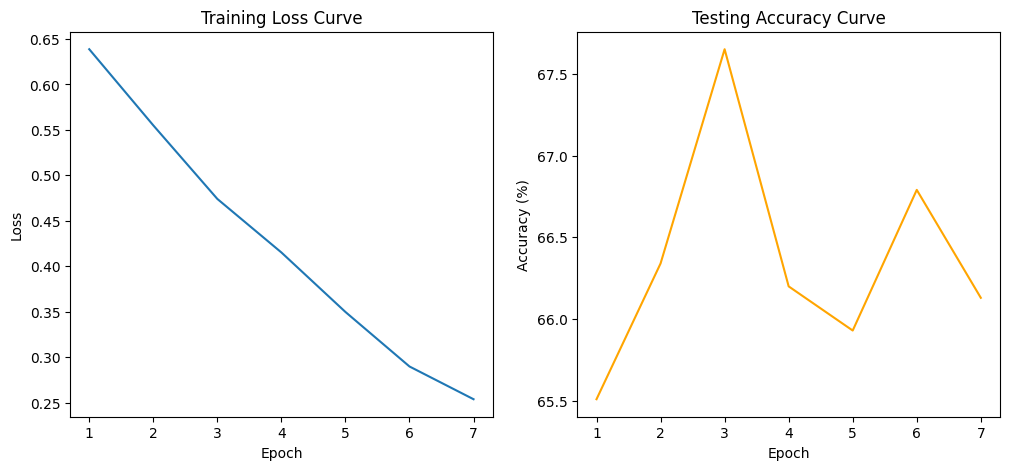

In [12]:
# -----------------------------
# Plot loss and accuracy curves
# -----------------------------
epochs_range = range(1, Epoch + 1)

plt.figure(figsize=(12, 5))

# Plot 1: Training Loss
plt.subplot(1, 2, 1)
plt.plot(epochs_range, train_losses, label='Training Loss')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Curve")

# Plot 2: Testing Accuracy
plt.subplot(1, 2, 2)
plt.plot(epochs_range, test_accs, label='Test Accuracy', color='orange')
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Testing Accuracy Curve")

plt.show()

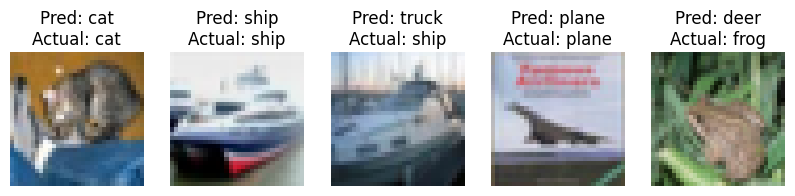

In [13]:
model.eval()
images, labels = next(iter(testloader))
images, labels = images.to(device), labels.to(device)

outputs = model(images)
_, predicted = torch.max(outputs, 1)

classes = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

plt.figure(figsize=(10, 4))
for i in range(5):
    plt.subplot(1, 5, i+1)
    img = images[i].cpu().numpy().transpose((1, 2, 0))
    img = img / 2 + 0.5
    plt.imshow(img)
    plt.title(f"Pred: {classes[predicted[i]]}\nActual: {classes[labels[i]]}")
    plt.axis('off')
plt.show()